# XGBoost — eXtreme Gradient Boosting
## Topic: Customer Churn + House Price Prediction


---

## 1. What is XGBoost?

> **Definition:** XGBoost (eXtreme Gradient Boosting) is an **optimized ensemble machine learning algorithm** that combines multiple weak learners (decision trees) sequentially, with each new tree correcting the errors of its predecessors. It incorporates **advanced regularization** and **optimization techniques** to prevent overfitting and improve performance.

**In one line:** XGBoost = Gradient Boosting + Regularization + Speed Optimizations.

**Why "eXtreme"?**
```
Traditional GBM:   correct, but slow and no regularization
XGBoost:           same idea + regularization in objective + parallel tree building
                   + cache-aware computation + GPU support + sparse data handling
```

XGBoost won or placed in the **top solutions of most Kaggle tabular data competitions** after its release (2016). It remains one of the most widely used ML algorithms for structured/tabular data.

---

## 2. XGBoost vs Traditional Gradient Boosting (GFG)

| Aspect | Traditional GBM (sklearn) | XGBoost Enhancement |
|--------|--------------------------|--------------------|
| **Regularization** | None built-in | L1 (alpha) + L2 (lambda) + gamma in objective |
| **Tree growth** | Depth-first | Level-wise (breadth-first) — better splits |
| **Missing values** | Needs imputation | Sparsity-aware — learns best default branch |
| **Memory** | Standard | Cache-aware block structure |
| **Speed** | Slow — greedy exact splits | Approximate histogram algorithm |
| **Parallel** | No | Yes — parallel split finding |
| **GPU** | No | Yes — full GPU support |
| **Scalability** | Limited | Handles 100M+ rows |
| **Early stopping** | Manual (staged_predict) | Built-in with eval_set |

---

## 3. How XGBoost Works — Step by Step (GFG)

```
STEP 1: Initial Base Learner
  → Train the first tree on raw data
  → Regression: predict mean of target
  → Classification: predict log-odds of the positive class

STEP 2: Error Calculation
  → Compute GRADIENTS (g) and HESSIANS (h) of the loss function
  → g = first derivative of loss (tells direction of error)
  → h = second derivative of loss (tells curvature — how confident)
  → For MSE: g = -(y - ŷ) = residual,  h = 1

STEP 3: Sequential Tree Training
  → Each new tree minimizes the regularized objective
  → Uses g and h to find optimal splits (not raw residuals)
  → Split gain formula uses BOTH gradient and Hessian

STEP 4: Iterative Refinement
  → Continue until n_estimators trees built or early stopping fires

STEP 5: Final Prediction
  → ŷ = sum of all tree predictions
  → ŷᵢ = Σ fₖ(xᵢ)  for all K trees
```

**XGBoost Data Structure:**
```python
# XGBoost's optimized data structure — DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test,  label=y_test)
# DMatrix stores data in column-major format for cache efficiency
# Also directly accepts missing values (NaN) — no imputation needed
```

---

## 4. The Objective Function — What XGBoost Minimizes (GFG)

XGBoost's power comes from its **regularized objective function**:

```
Obj = Σ L(yᵢ, ŷᵢ)  +  Ω(fₜ)
      ─────────────    ──────────
       Training loss    Regularization

Where:
  L(yᵢ, ŷᵢ) = loss between actual and predicted
  Ω(fₜ) = γT + ½λΣwⱼ²    ← GFG formula

  γ = minimum loss reduction required to make a split (structural regularization)
  λ = L2 regularization on leaf weights
  T = number of leaves in the tree
  wⱼ = weight (score) of leaf j
```

**This means XGBoost penalizes:**
- Complex trees (too many leaves) → via γ and T
- Large leaf weights → via λ

---

## 5. Split Gain Formula (GFG)

XGBoost uses gradient (g) and Hessian (h) to evaluate every possible split:

```
Gain = ½ × [ (ΣGₗ)²/(ΣHₗ+λ) + (ΣGᵣ)²/(ΣHᵣ+λ) - (ΣG)²/(ΣH+λ) ] - γ
            ────────────────    ────────────────    ──────────────
            Left child score    Right child score   Parent score

Where:
  Gₗ, Gᵣ = sum of gradients in left and right child
  Hₗ, Hᵣ = sum of Hessians in left and right child
  λ = L2 regularization term
  γ = minimum gain threshold (split only if Gain > 0)

Leaf weight formula:
  wⱼ = -(Σgᵢ) / (Σhᵢ + λ)     ← λ shrinks leaf weights (L2 regularization)
```

**Intuition:** A split is only made if it improves the objective by more than γ. This is a **built-in pruning mechanism** — no separate pruning step needed.

---

## 6. Regularization in XGBoost (GFG)

XGBoost has **three types of regularization built into the objective**:

| Parameter | Type | Effect |
|-----------|------|--------|
| `gamma` (γ) | Structural | Minimum loss reduction for a split — prunes weak splits |
| `reg_lambda` (λ) | L2 | Penalizes large leaf weights — smooth predictions |
| `reg_alpha` (α) | L1 | Encourages sparse leaf weights — sets some to zero |

```
Traditional GBM overfits  → no regularization in objective
XGBoost resists overfitting → regularization is PART of what it optimizes

Also regularized via:
  subsample       → stochastic row sampling per tree
  colsample_bytree → stochastic column sampling per tree
  min_child_weight → minimum Hessian sum in a leaf node
```

---

## 7. Key Parameters (GFG)

| Parameter | Default | Range | What it controls |
|-----------|---------|-------|------------------|
| `n_estimators` | 100 | 50-500 | Number of boosting rounds |
| `learning_rate` (η) | 0.3 | 0.01-0.2 | Shrinkage per tree |
| `max_depth` | 6 | 3-9 | Max tree depth |
| `gamma` (γ) | 0 | 0-5 | Min loss reduction for split — higher = more conservative |
| `subsample` | 1 | 0.8-1.0 | Row sampling fraction |
| `colsample_bytree` | 1 | 0.8-1.0 | Feature sampling per tree |
| `reg_alpha` (α) | 0 | 0+ | L1 regularization on leaf weights |
| `reg_lambda` (λ) | 1 | 1+ | L2 regularization on leaf weights |
| `min_child_weight` | 1 | 1+ | Min sum of Hessians in leaf |
| `scale_pos_weight` | 1 | varies | For imbalanced: sum(neg)/sum(pos) |
| `objective` | auto | — | 'binary:logistic', 'reg:squarederror', 'multi:softmax' |
| `tree_method` | 'auto' | — | 'hist' for large data, 'gpu_hist' for GPU |
| `eval_metric` | varies | — | 'logloss', 'rmse', 'auc' etc. |

---

## 8. Handling Missing Values (GFG)

Unlike sklearn's GBM, XGBoost handles missing values natively:

```
At each split, XGBoost tries sending missing-value samples:
  → to the LEFT child
  → to the RIGHT child
  → keeps whichever gives better split score

This is called the 'sparsity-aware split finding' algorithm.
The learned default direction is stored in the tree.
→ No imputation needed!
```

---

## 9. Feature Importance Types in XGBoost (GFG)

XGBoost has **three built-in importance metrics** — more options than sklearn's GBM:

| Type | What it measures |
|------|------------------|
| `weight` | Number of times a feature appears in a split across all trees |
| `gain` | Average gain of splits that use the feature (quality of splits) |
| `cover` | Average coverage (number of samples affected) of splits using feature |

**GFG recommendation:** Use `gain` — it measures how much each feature actually improves the model, not just how often it's used.

---

## 10. Advantages and Disadvantages (GFG)

### Advantages
| # | Advantage | Detail |
|---|-----------|--------|
| 1 | Superior predictive accuracy | Especially on structured/tabular data |
| 2 | Scalability | Parallel tree building, GPU support, handles 100M+ rows |
| 3 | Native missing value handling | No imputation needed |
| 4 | Built-in regularization | L1 + L2 + gamma in objective function |
| 5 | Built-in early stopping | Stops when eval metric stops improving |
| 6 | Flexible objectives | Regression, classification, ranking, survival |
| 7 | Multiple importance types | weight, gain, cover |
| 8 | Cross-platform | Python, R, Java, Spark, etc. |

### Disadvantages (GFG)
| # | Disadvantage | Fix |
|---|-------------|-----|
| 1 | Computationally intensive | Use GPU, reduce n_estimators |
| 2 | Many hyperparameters to tune | Use Optuna or Bayesian optimization |
| 3 | Sensitive to outliers | Clip outliers before training |
| 4 | Overfitting on small datasets | Add regularization (gamma, lambda) |
| 5 | Not interpretable | Use SHAP (built into XGBoost) |
| 6 | Memory-heavy for large forests | Use LightGBM instead |

---

## 11. When to Use XGBoost vs LightGBM vs CatBoost

| Scenario | Best Choice |
|----------|-------------|
| General tabular data | XGBoost |
| Very large dataset (1M+ rows), speed critical | LightGBM |
| Many categorical features | CatBoost |
| GPU training needed | All three support it |
| Interpretability (SHAP) | XGBoost (native SHAP support) |
| Easy hyperparameter tuning | CatBoost |

---

## 12. Real-World Applications

| Domain | Use Case |
|--------|----------|
| Finance | Fraud detection, credit scoring |
| E-commerce | Click-through rate, recommendation |
| Healthcare | Disease risk prediction |
| Kaggle | Wins most structured-data competitions |
| NLP | Feature-based text classification |
| Time series | Tabular time series forecasting |

---
# Implementation: Customer Churn + House Price Prediction
---

In [1]:
# Step 1: Install and Import XGBoost
# If not installed: pip install xgboost
import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    mean_squared_error, r2_score, mean_absolute_error
)
from sklearn.datasets import fetch_california_housing
import warnings
warnings.filterwarnings('ignore')

print(f'XGBoost version : {xgb.__version__}')
print('Libraries loaded successfully!')

XGBoost version : 3.2.0
Libraries loaded successfully!


In [2]:
# Step 2: Build Customer Churn Dataset
np.random.seed(42)
n_churn, n_stay = 150, 300

churn = {
    'tenure_months':     np.random.randint(1, 18, n_churn),
    'monthly_charges':   np.random.uniform(70, 120, n_churn),
    'num_products':      np.random.randint(1, 3, n_churn),
    'has_tech_support':  np.random.choice([0,1], n_churn, p=[0.75,0.25]),
    'contract_type':     np.random.choice([0,1,2], n_churn, p=[0.70,0.20,0.10]),
    'payment_method':    np.random.choice([0,1,2,3], n_churn),
    'num_support_calls': np.random.randint(3, 10, n_churn),
    'label': [1]*n_churn
}
stay = {
    'tenure_months':     np.random.randint(12, 72, n_stay),
    'monthly_charges':   np.random.uniform(40, 85, n_stay),
    'num_products':      np.random.randint(2, 5, n_stay),
    'has_tech_support':  np.random.choice([0,1], n_stay, p=[0.30,0.70]),
    'contract_type':     np.random.choice([0,1,2], n_stay, p=[0.20,0.40,0.40]),
    'payment_method':    np.random.choice([0,1,2,3], n_stay),
    'num_support_calls': np.random.randint(0, 4, n_stay),
    'label': [0]*n_stay
}

df = pd.concat([pd.DataFrame(churn), pd.DataFrame(stay)],
               ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

features = ['tenure_months','monthly_charges','num_products',
            'has_tech_support','contract_type','payment_method','num_support_calls']
X, y = df[features], df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Dataset: {df.shape} | Train: {X_train.shape} | Test: {X_test.shape}')
print(df['label'].value_counts().rename({0:'Stayed',1:'Churned'}))

Dataset: (450, 8) | Train: (360, 7) | Test: (90, 7)
Stayed     300
Churned    150
Name: label, dtype: int64


In [3]:
# Step 3: DMatrix — XGBoost's Optimized Data Structure (GFG)
print('DMatrix — XGBoost Optimized Data Structure (GFG)')
print('=' * 55)

# Method 1: DMatrix (native XGBoost API — faster, more control)
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dtest  = xgb.DMatrix(X_test,  label=y_test,  feature_names=features)

print(f'DMatrix train shape : {dtrain.num_row()} rows x {dtrain.num_col()} cols')
print(f'DMatrix test  shape : {dtest.num_row()} rows x {dtest.num_col()} cols')
print()
print('DMatrix benefits (GFG):')
print('  1. Column-major storage → cache-efficient for tree building')
print('  2. Stores missing values (NaN) directly — no imputation needed')
print('  3. Can be saved/loaded: dtrain.save_binary("train.buffer")')
print('  4. Faster than pandas DataFrame for XGBoost training')

DMatrix — XGBoost Optimized Data Structure (GFG)
DMatrix train shape : 360 rows x 7 cols
DMatrix test  shape : 90 rows x 7 cols

DMatrix benefits (GFG):
  1. Column-major storage → cache-efficient for tree building
  2. Stores missing values (NaN) directly — no imputation needed
  3. Can be saved/loaded: dtrain.save_binary("train.buffer")
  4. Faster than pandas DataFrame for XGBoost training


In [4]:
# Step 4: Train XGBoost — Two APIs (native vs sklearn)

# --- Native API (more control) ---
params_native = {
    'objective':        'binary:logistic',
    'max_depth':        4,
    'learning_rate':    0.1,
    'n_estimators':     100,
    'gamma':            0.1,        # min loss reduction for split
    'reg_alpha':        0.1,        # L1 regularization
    'reg_lambda':       1.0,        # L2 regularization
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'eval_metric':      'logloss',
    'seed':             42,
}
evals_result = {}
xgb_native = xgb.train(
    params_native, dtrain,
    num_boost_round=100,
    evals=[(dtrain,'train'), (dtest,'eval')],
    evals_result=evals_result,
    verbose_eval=False
)

# --- Sklearn API (familiar interface) ---
xgb_sklearn = xgb.XGBClassifier(
    n_estimators=100, learning_rate=0.1,
    max_depth=4, gamma=0.1,
    reg_alpha=0.1, reg_lambda=1.0,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42,
    use_label_encoder=False
)
xgb_sklearn.fit(X_train, y_train)

# --- Compare with other models ---
gbm = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
rf  = RandomForestClassifier(n_estimators=100, random_state=42)
for m in [gbm, rf]: m.fit(X_train, y_train)

# Native API predictions
y_prob_native = xgb_native.predict(dtest)
y_pred_native = (y_prob_native > 0.5).astype(int)

print('=' * 65)
print('MODEL COMPARISON')
print('=' * 65)
print(f'{"Model":<35} {"Test Acc":>10} {"ROC-AUC":>10}')
print('-' * 60)

models_eval = [
    ('XGBoost (native API)',  y_pred_native,               y_prob_native),
    ('XGBoost (sklearn API)', xgb_sklearn.predict(X_test), xgb_sklearn.predict_proba(X_test)[:,1]),
    ('GBM (sklearn)',         gbm.predict(X_test),         gbm.predict_proba(X_test)[:,1]),
    ('Random Forest',         rf.predict(X_test),          rf.predict_proba(X_test)[:,1]),
]
for name, preds, probs in models_eval:
    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)
    print(f'{name:<35} {acc:>10.4f} {auc:>10.4f}')

MODEL COMPARISON
Model                                 Test Acc    ROC-AUC
------------------------------------------------------------
XGBoost (native API)                    1.0000     1.0000
XGBoost (sklearn API)                   1.0000     1.0000
GBM (sklearn)                           1.0000     1.0000
Random Forest                           1.0000     1.0000


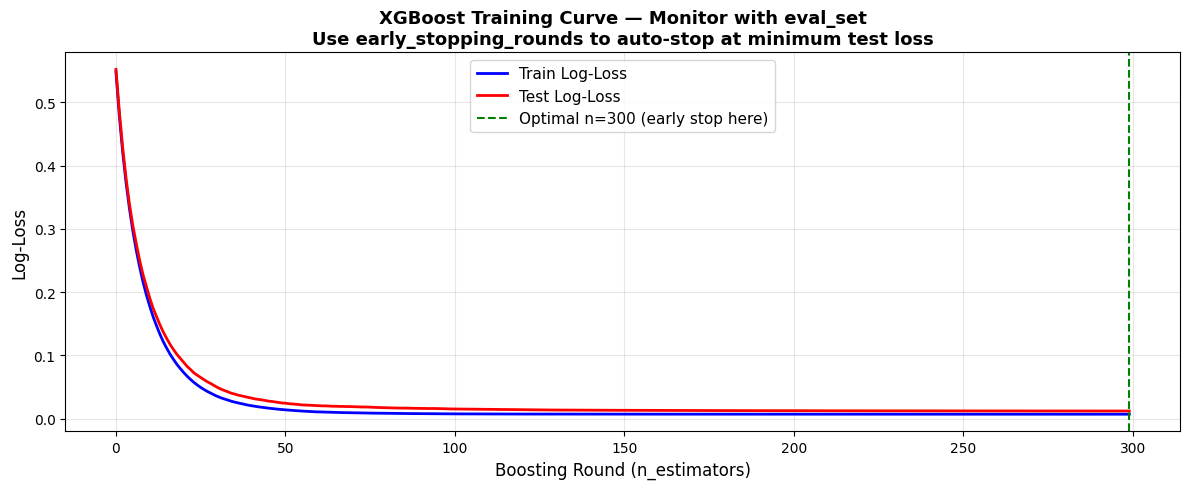

Optimal n_estimators (min test loss) : 300
Use early_stopping_rounds=10 to find this automatically!


In [5]:
# Step 5: Training Curve — Monitor Overfitting with eval_set
xgb_monitor = xgb.XGBClassifier(
    n_estimators=300, learning_rate=0.1, max_depth=4,
    eval_metric='logloss', random_state=42
)
xgb_monitor.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

train_loss = xgb_monitor.evals_result()['validation_0']['logloss']
test_loss  = xgb_monitor.evals_result()['validation_1']['logloss']
optimal_n  = np.argmin(test_loss) + 1

plt.figure(figsize=(12, 5))
plt.plot(train_loss, 'b-', linewidth=2, label='Train Log-Loss')
plt.plot(test_loss,  'r-', linewidth=2, label='Test Log-Loss')
plt.axvline(x=optimal_n-1, color='green', linestyle='--',
            label=f'Optimal n={optimal_n} (early stop here)')
plt.xlabel('Boosting Round (n_estimators)', fontsize=12)
plt.ylabel('Log-Loss', fontsize=12)
plt.title('XGBoost Training Curve — Monitor with eval_set\n'
          'Use early_stopping_rounds to auto-stop at minimum test loss',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Optimal n_estimators (min test loss) : {optimal_n}')
print('Use early_stopping_rounds=10 to find this automatically!')

In [6]:
# Step 6: Early Stopping — Built-in XGBoost Feature (GFG)
xgb_early = xgb.XGBClassifier(
    n_estimators=1000,          # upper limit
    learning_rate=0.1,
    max_depth=4,
    eval_metric='logloss',
    early_stopping_rounds=20,   # stop if no improvement for 20 rounds
    random_state=42
)
xgb_early.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print('Early Stopping Results')
print('=' * 45)
print(f'Best iteration     : {xgb_early.best_iteration}')
print(f'Best score (logloss): {xgb_early.best_score:.4f}')
print(f'Test Accuracy      : {xgb_early.score(X_test, y_test):.4f}')
print()
print('GFG advantage: Early stopping avoids overfitting AND reduces training time')
print('Set n_estimators=1000 (high limit) and let early stopping find optimal trees')

Early Stopping Results
Best iteration     : 419
Best score (logloss): 0.0118
Test Accuracy      : 1.0000

GFG advantage: Early stopping avoids overfitting AND reduces training time
Set n_estimators=1000 (high limit) and let early stopping find optimal trees


In [7]:
# Step 7: Regularization Effect — gamma, alpha, lambda (GFG)
reg_configs = [
    {'label': 'No Regularization',       'gamma':0,   'reg_alpha':0,   'reg_lambda':0},
    {'label': 'L2 only (lambda=1)',       'gamma':0,   'reg_alpha':0,   'reg_lambda':1},
    {'label': 'L1 only (alpha=1)',        'gamma':0,   'reg_alpha':1,   'reg_lambda':0},
    {'label': 'Gamma only (gamma=1)',     'gamma':1,   'reg_alpha':0,   'reg_lambda':0},
    {'label': 'All regularization',       'gamma':0.5, 'reg_alpha':0.5, 'reg_lambda':1},
]

print('Regularization Effect on XGBoost (GFG)')
print('=' * 65)
print(f'{"Config":<35} {"Train Acc":>10} {"Test Acc":>10} {"ROC-AUC":>10}')
print('-' * 70)

for cfg in reg_configs:
    m = xgb.XGBClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=4,
        gamma=cfg['gamma'], reg_alpha=cfg['reg_alpha'], reg_lambda=cfg['reg_lambda'],
        eval_metric='logloss', random_state=42, verbosity=0
    )
    m.fit(X_train, y_train)
    tr  = accuracy_score(y_train, m.predict(X_train))
    te  = accuracy_score(y_test,  m.predict(X_test))
    auc = roc_auc_score(y_test, m.predict_proba(X_test)[:,1])
    print(f'{cfg["label"]:<35} {tr:>10.4f} {te:>10.4f} {auc:>10.4f}')

print('\nGFG: gamma prunes weak splits; lambda smooths leaf weights; alpha sparsifies weights')

Regularization Effect on XGBoost (GFG)
Config                               Train Acc   Test Acc    ROC-AUC
----------------------------------------------------------------------
No Regularization                       1.0000     1.0000     1.0000
L2 only (lambda=1)                      1.0000     1.0000     1.0000
L1 only (alpha=1)                       1.0000     1.0000     1.0000
Gamma only (gamma=1)                    1.0000     0.9889     1.0000
All regularization                      0.9972     0.9889     1.0000

GFG: gamma prunes weak splits; lambda smooths leaf weights; alpha sparsifies weights


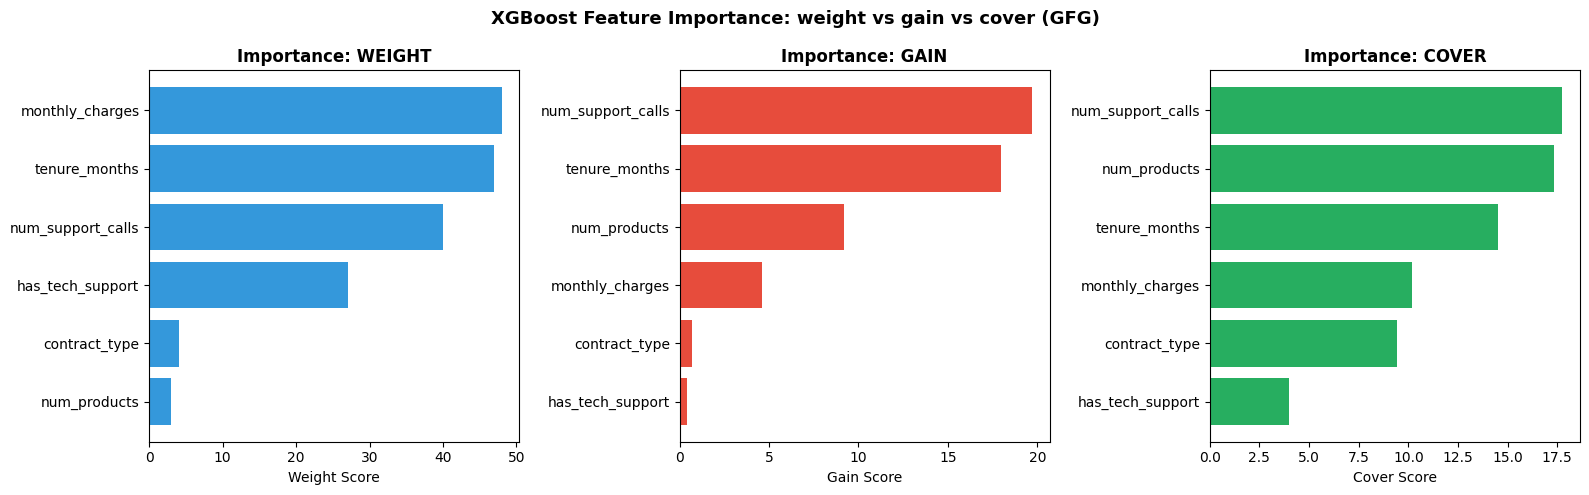

Feature Importance Table (sorted by gain):
          Feature  weight      gain     cover
num_support_calls    40.0 19.706245 17.757694
    tenure_months    47.0 17.981293 14.527214
     num_products     3.0  9.208491 17.317722
  monthly_charges    48.0  4.638349 10.195690
    contract_type     4.0  0.699236  9.412394
 has_tech_support    27.0  0.414205  4.008439

GFG: Use GAIN — measures quality of splits, not just frequency (weight)


In [8]:
# Step 8: Feature Importance — Three Types (GFG: weight, gain, cover)
booster = xgb_sklearn.get_booster()

imp_types = ['weight', 'gain', 'cover']
imp_dfs = {}
for t in imp_types:
    scores = booster.get_score(importance_type=t)
    imp_dfs[t] = pd.DataFrame({'Feature': list(scores.keys()),
                                t: list(scores.values())})

# Merge all three
merged = imp_dfs['weight']
for t in ['gain', 'cover']:
    merged = merged.merge(imp_dfs[t], on='Feature', how='outer').fillna(0)
merged = merged.sort_values('gain', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#3498db', '#e74c3c', '#27ae60']
for ax, t, color in zip(axes, imp_types, colors):
    sorted_df = merged.sort_values(t, ascending=True)
    ax.barh(sorted_df['Feature'], sorted_df[t], color=color)
    ax.set_xlabel(f'{t.capitalize()} Score')
    ax.set_title(f'Importance: {t.upper()}', fontsize=12, fontweight='bold')

plt.suptitle('XGBoost Feature Importance: weight vs gain vs cover (GFG)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Feature Importance Table (sorted by gain):')
print(merged.to_string(index=False))
print('\nGFG: Use GAIN — measures quality of splits, not just frequency (weight)')

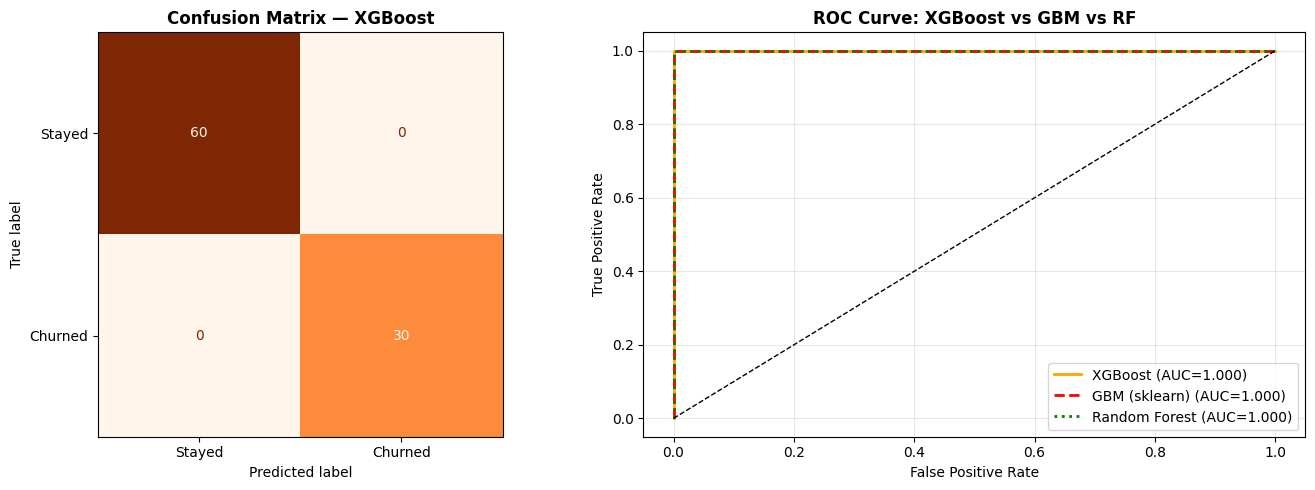

CLASSIFICATION REPORT — XGBoost
              precision    recall  f1-score   support

      Stayed       1.00      1.00      1.00        60
     Churned       1.00      1.00      1.00        30

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90



In [9]:
# Step 9: Confusion Matrix & ROC Curve
y_pred_xgb = xgb_sklearn.predict(X_test)
y_prob_xgb = xgb_sklearn.predict_proba(X_test)[:,1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(cm, display_labels=['Stayed','Churned']).plot(
    ax=axes[0], colorbar=False, cmap='Oranges')
axes[0].set_title('Confusion Matrix — XGBoost', fontsize=12, fontweight='bold')

for name, model, color, ls in [
    ('XGBoost',       xgb_sklearn, 'orange', '-'),
    ('GBM (sklearn)', gbm,         'red',    '--'),
    ('Random Forest', rf,          'green',  ':'),
]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    axes[1].plot(fpr, tpr, color=color, linestyle=ls, linewidth=2,
                 label=f'{name} (AUC={auc:.3f})')

axes[1].plot([0,1],[0,1],'k--', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve: XGBoost vs GBM vs RF', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('CLASSIFICATION REPORT — XGBoost')
print('=' * 50)
print(classification_report(y_test, y_pred_xgb, target_names=['Stayed','Churned']))

XGBoost Regression — California Housing (GFG example)
RMSE              : 0.4840
MAE               : 0.3268
R2 Score          : 0.8212
Best iteration    : 199


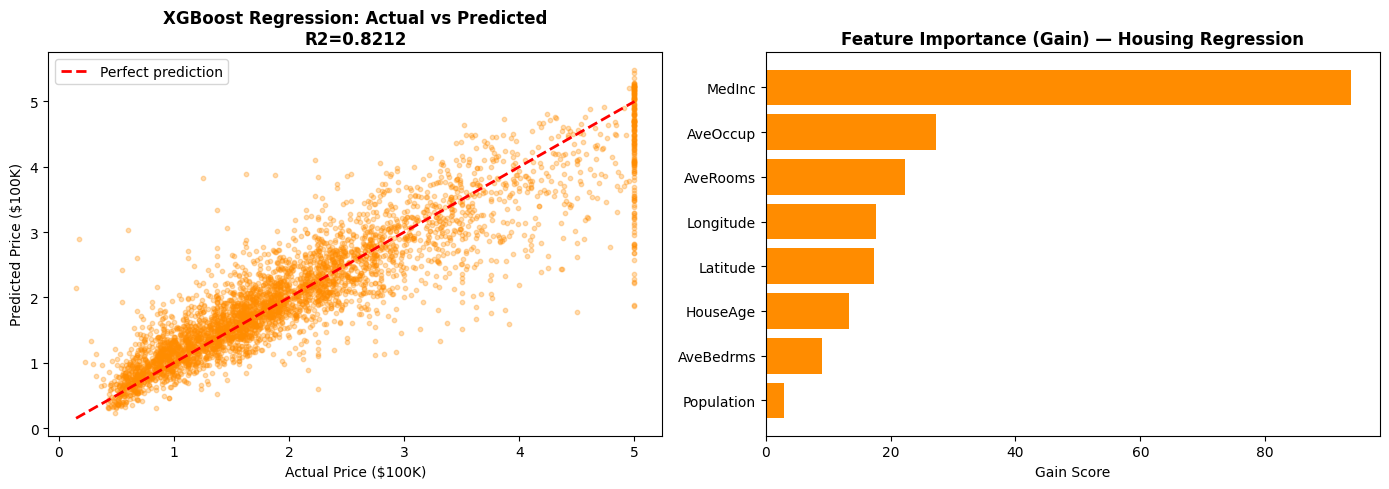

In [10]:
# Step 10: XGBoost Regression — California Housing (GFG example)
housing = fetch_california_housing()
X_reg = pd.DataFrame(housing.data, columns=housing.feature_names)
y_reg = housing.target

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

xgb_reg = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=200, learning_rate=0.1,
    max_depth=4, subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    early_stopping_rounds=20,
    eval_metric='rmse', random_state=42
)
xgb_reg.fit(X_tr_r, y_tr_r,
             eval_set=[(X_te_r, y_te_r)], verbose=False)

y_pred_r = xgb_reg.predict(X_te_r)
rmse = np.sqrt(mean_squared_error(y_te_r, y_pred_r))
mae  = mean_absolute_error(y_te_r, y_pred_r)
r2   = r2_score(y_te_r, y_pred_r)

print('XGBoost Regression — California Housing (GFG example)')
print('=' * 55)
print(f'RMSE              : {rmse:.4f}')
print(f'MAE               : {mae:.4f}')
print(f'R2 Score          : {r2:.4f}')
print(f'Best iteration    : {xgb_reg.best_iteration}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_te_r, y_pred_r, alpha=0.3, color='darkorange', s=10)
axes[0].plot([y_te_r.min(), y_te_r.max()], [y_te_r.min(), y_te_r.max()],
             'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Price ($100K)')
axes[0].set_ylabel('Predicted Price ($100K)')
axes[0].set_title(f'XGBoost Regression: Actual vs Predicted\nR2={r2:.4f}',
                  fontsize=12, fontweight='bold')
axes[0].legend()

# Feature importance (gain)
feat_imp = xgb_reg.get_booster().get_score(importance_type='gain')
fi_df = pd.DataFrame({'Feature': list(feat_imp.keys()),
                       'Gain':   list(feat_imp.values())}).sort_values('Gain', ascending=True)
axes[1].barh(fi_df['Feature'], fi_df['Gain'], color='darkorange')
axes[1].set_xlabel('Gain Score')
axes[1].set_title('Feature Importance (Gain) — Housing Regression',
                  fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [11]:
# Step 11: Handle Imbalanced Classes — scale_pos_weight (GFG)
# Create imbalanced dataset
stay_idx  = df[df['label']==0].index
churn_idx = df[df['label']==1].index[:30]
df_imb = df.loc[list(stay_idx)+list(churn_idx)].reset_index(drop=True)

Xi, yi = df_imb[features], df_imb['label']
X_tr_i, X_te_i, y_tr_i, y_te_i = train_test_split(Xi, yi, test_size=0.2, random_state=42, stratify=yi)

neg = (y_tr_i == 0).sum()
pos = (y_tr_i == 1).sum()
scale = neg / pos

print(f'Imbalanced dataset: {neg} stayed | {pos} churned')
print(f'scale_pos_weight = {neg}/{pos} = {scale:.2f}\n')

xgb_default  = xgb.XGBClassifier(n_estimators=100, random_state=42, verbosity=0)
xgb_balanced = xgb.XGBClassifier(n_estimators=100, random_state=42,
                                   scale_pos_weight=scale, verbosity=0)

xgb_default.fit(X_tr_i, y_tr_i)
xgb_balanced.fit(X_tr_i, y_tr_i)

print(f'{"Model":<35} {"Accuracy":>10} {"ROC-AUC":>10}')
print('-' * 58)
for name, model in [('XGBoost Default', xgb_default), ('XGBoost scale_pos_weight', xgb_balanced)]:
    acc = accuracy_score(y_te_i, model.predict(X_te_i))
    auc = roc_auc_score(y_te_i, model.predict_proba(X_te_i)[:,1])
    print(f'{name:<35} {acc:>10.4f} {auc:>10.4f}')

print('\nGFG: scale_pos_weight = sum(negative) / sum(positive)')
print('     Tells XGBoost to penalize missing minority class more heavily')

Imbalanced dataset: 240 stayed | 24 churned
scale_pos_weight = 240/24 = 10.00

Model                                 Accuracy    ROC-AUC
----------------------------------------------------------
XGBoost Default                         1.0000     1.0000
XGBoost scale_pos_weight                1.0000     1.0000

GFG: scale_pos_weight = sum(negative) / sum(positive)
     Tells XGBoost to penalize missing minority class more heavily


In [12]:
# Step 12: Hyperparameter Tuning — GridSearchCV (GFG)
param_grid = {
    'max_depth':        [3, 5],
    'learning_rate':    [0.05, 0.1],
    'n_estimators':     [100, 200],
    'subsample':        [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma':            [0, 0.5],
}

grid = GridSearchCV(
    xgb.XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0),
    param_grid, cv=5, scoring='roc_auc', n_jobs=-1
)
grid.fit(X_train, y_train)
best_xgb = grid.best_estimator_

print('GridSearchCV Results — XGBoost')
print('=' * 50)
print(f'Best Params   : {grid.best_params_}')
print(f'Best CV AUC   : {grid.best_score_:.4f}')
print(f'Test AUC      : {roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:,1]):.4f}')
print(f'Test Accuracy : {best_xgb.score(X_test, y_test):.4f}')

GridSearchCV Results — XGBoost
Best Params   : {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV AUC   : 1.0000
Test AUC      : 1.0000
Test Accuracy : 1.0000


In [13]:
# Step 13: Live Prediction Demo
new_customers = pd.DataFrame({
    'tenure_months':     [2,  48,  6,  60],
    'monthly_charges':   [95, 55, 110, 45],
    'num_products':      [1,   4,   1,  3],
    'has_tech_support':  [0,   1,   0,  1],
    'contract_type':     [0,   2,   0,  1],
    'payment_method':    [0,   2,   0,  3],
    'num_support_calls': [7,   1,   8,  0],
})
descs = [
    'New, high charges, month-to-month, many complaints',
    'Long-term, low charges, 2-year contract',
    'Short tenure, very high charges, many calls',
    'Long tenure, low charges, 1-year contract',
]
preds = xgb_sklearn.predict(new_customers)
probs = xgb_sklearn.predict_proba(new_customers)

print('=' * 65)
print('LIVE CHURN PREDICTION — XGBoost')
print('=' * 65)
for desc, pred, prob in zip(descs, preds, probs):
    label = 'CHURN' if pred == 1 else 'STAY'
    risk  = 'HIGH' if prob[1]>0.7 else 'MEDIUM' if prob[1]>0.4 else 'LOW'
    print(f'\nCustomer: "{desc}"')
    print(f'  Prediction : {label}')
    print(f'  Confidence : Stay={prob[0]:.0%} | Churn={prob[1]:.0%}')
    print(f'  Risk Level : {risk}')

LIVE CHURN PREDICTION — XGBoost

Customer: "New, high charges, month-to-month, many complaints"
  Prediction : CHURN
  Confidence : Stay=0% | Churn=100%
  Risk Level : HIGH

Customer: "Long-term, low charges, 2-year contract"
  Prediction : STAY
  Confidence : Stay=100% | Churn=0%
  Risk Level : LOW

Customer: "Short tenure, very high charges, many calls"
  Prediction : CHURN
  Confidence : Stay=0% | Churn=100%
  Risk Level : HIGH

Customer: "Long tenure, low charges, 1-year contract"
  Prediction : STAY
  Confidence : Stay=100% | Churn=0%
  Risk Level : LOW


---

## Master Cheat Sheet — Everything in One Place

| Concept | One-liner |
|---------|----------|
| XGBoost | GBM + L1/L2/gamma regularization + speed optimizations |
| Objective (GFG) | Obj = Σ L(y,ŷ) + Ω(f) — loss + regularization |
| Regularization Ω | γT + ½λΣwⱼ² — penalizes leaves and large weights |
| Split Gain (GFG) | ½[Gₗ²/(Hₗ+λ) + Gᵣ²/(Hᵣ+λ) - G²/(H+λ)] - γ |
| Leaf weight | wⱼ = -(Σg)/(Σh+λ) — λ shrinks it (L2) |
| DMatrix | XGBoost's cache-efficient data structure |
| gamma (γ) | Min loss reduction for split — prunes weak splits |
| reg_lambda (λ) | L2 on leaf weights — smooth |
| reg_alpha (α) | L1 on leaf weights — sparse |
| scale_pos_weight | sum(neg)/sum(pos) — fixes class imbalance |
| early_stopping_rounds | Auto-stop when eval metric plateaus |
| Importance: gain (GFG) | Best metric — quality of splits, not frequency |
| tree_method='hist' | Histogram algorithm — fast for large datasets |

---

## Hyperparameter Quick Reference (GFG)

| Parameter | Default | Range | Tip |
|-----------|---------|-------|-----|
| `n_estimators` | 100 | 50-500 | Set high + use early stopping |
| `learning_rate` | 0.3 | 0.01-0.2 | Lower = better; GFG uses 0.05-0.1 |
| `max_depth` | 6 | 3-9 | GFG range: 3-9 |
| `gamma` | 0 | 0-5 | Increase to prevent small splits |
| `subsample` | 1 | 0.8-1.0 | Row sampling — reduces variance |
| `colsample_bytree` | 1 | 0.8-1.0 | Feature sampling per tree |
| `reg_alpha` | 0 | 0+ | L1 — use for sparse data |
| `reg_lambda` | 1 | 1+ | L2 — always helpful |
| `min_child_weight` | 1 | 1+ | Higher = fewer leaves |
| `scale_pos_weight` | 1 | neg/pos | For imbalanced datasets |

---

## Quick Math (GFG)

```
Objective         : Obj = Σ L(yᵢ, ŷᵢ) + Ω(fₜ)
Regularization    : Ω(fₜ) = γT + ½λΣwⱼ²
Final prediction  : ŷᵢ = Σ fₖ(xᵢ)  (sum over all K trees)
Split Gain        : ½[Gₗ²/(Hₗ+λ) + Gᵣ²/(Hᵣ+λ) - G²/(H+λ)] - γ
Leaf weight       : wⱼ = -(Σgᵢ)/(Σhᵢ + λ)
For MSE loss      : g = ŷ - y  (gradient),  h = 1  (Hessian)
```

---

## XGBoost vs GBM vs Random Forest

| Property | Random Forest | GBM (sklearn) | XGBoost |
|----------|--------------|--------------|--------|
| Order | Parallel | Sequential | Sequential |
| Regularization | None | None | L1 + L2 + gamma |
| Missing values | No | No | Yes (sparsity-aware) |
| Speed | Fast | Slow | Fast (hist algorithm) |
| Early stopping | No | Manual | Built-in |
| GPU | No | No | Yes |
| Overfitting control | n_estimators safe | Careful tuning | Regularization + early stop |
| Importance types | 1 (MDI) | 1 (MDI) | 3 (weight, gain, cover) |
| Best for | Robust baseline | Moderate tabular | Best tabular accuracy |